# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

0
0.7619342359767892
subject_injury               Missing    No   Yes
force_type                                      
Baton                              2     0     2
Bodily Force                    7051  1093  1286
Chemical Irritant               1421   131    41
Firearm                            0     2     0
Gun Point Display                 27    33    44
Improvised Weapon                 74    34    40
Less Lethal                       87     0     0
Less Lethal Projectile             0     1     2
Maximal Restraint Technique      170     0     0
Police K9 Bite                    31     2    44
Taser                            985   150   172
count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64
0.787134922056979
0.7459236695932628


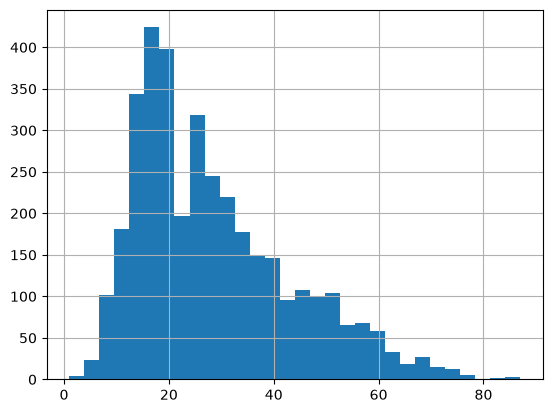

In [ ]:
# Your Phase 1 solution to the problem goes here.

import numpy as np
import pandas as pd

# Question 1
# Part 1: To clean Price in the airbnb.csv you need to convert prices to numbers. I'm going to remove commas first to fix 
# formatting then convert to numbers.
airbnb = pd.read_csv('data/airbnb_hw.csv')

airbnb['Price'] = airbnb['Price'].astype(str).str.replace(',', '', regex = False)
airbnb['Price'] = pd.to_numeric(airbnb['Price'], errors = 'coerce')
airbnb['Price_nan'] = airbnb['Price'].isnull()

# Every price converted successfully so 0 missing values (printed 0).
print(airbnb['Price_nan'].sum())
  
# Part 2: To clean subject_injury in the mn_police_use_of_force.csv you need to handle NAs by flagging them as missing
# instead of assuming a blank means no injury.

policeforce = pd.read_csv('data/mn_police_use_of_force.csv')
policeforce['subject_injury_nan'] = policeforce['subject_injury'].isnull()

# Proportion of values missing
prop_missing = policeforce['subject_injury'].isnull().mean()
print(prop_missing)

# This proportion is a concern because about 76% of rows are missing this value, which is probably too much to ignore.

# Cross tabulate cleaned subject_injury with force_type to check for patterns in missingness.
ct_subject_force = pd.crosstab(policeforce['force_type'], policeforce['subject_injury'].fillna('Missing'))
print(ct_subject_force)

# There is a clear pattern by force_type: the most common force types (Bodily Force, Chemical Irritant, Taser) are missing 
# subject_injury most often, while rare/severe force types (Firearm, Less Lethal Projectile) have 0% missing (though these 
# categories only have 2-3 total incidents, so that part of the pattern is based on not a lot of data).

# ------------------------------------------------------------------------------------------------------------------------

# Question 2
# Part 1: Open shark attack file and read it in (not .csv so for Exel do .xls)
sharkattack = pd.read_excel('data/GSAF5.xls')

# Part 2: Drop columns that do not contain data
sharkattack = sharkattack.dropna(axis = 1, how = 'all')

# Part 3: Clean  Year variable, convert to numeric, then filter to attacks since 1940.
sharkattack['Year'] = pd.to_numeric(sharkattack['Year'], errors = 'coerce')
sharkattack['Year_nan'] = sharkattack['Year'].isnull()
print(sharkattack['Year'].describe())
# Range of values that are see are from 0 to 2026. Attacks historically are increasing with a slight decline in the 2020s years.

sharkattack1 = sharkattack[sharkattack['Year'] >= 1940]

# Part 4: Clean Age variable and make histogram of victim ages.
sharkattack1['Age'] = pd.to_numeric(sharkattack1['Age'], errors = 'coerce')
sharkattack1['Age_nan'] = sharkattack1['Age'].isnull()
sharkattack1['Age'].hist(bins = 30)

# Part 5: What proportion of victims are male? 
# Sex has inconsistant entries so strip whitespace and force all uppercase.
sharkattack1['Sex'] = sharkattack1['Sex'].str.strip().str.upper()
prop_male = (sharkattack1['Sex'] == 'M').mean()
print(prop_male)
# About 79% of victims are male.

# Part 6: Clean Type variable so it only takes 3 values: Provoked, Unprovoked, Unknown.
# Type also has messy entries so strip whitespace and standarzise cases.
sharkattack1['Type'] = sharkattack1['Type'].str.strip().str.title()
sharkattack1.loc[~sharkattack1['Type'].isin(['Provoked', 'Unprovoked']), 'Type'] = 'Unknown'
prop_unprovoked = (sharkattack1['Type'] == 'Unprovoked').mean()
print(prop_unprovoked)
# About 75% of attacks are unprovoked.



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]